In [78]:

import allensdk
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
import tqdm
from scipy.ndimage import gaussian_filter1d
import pre_process_spikes as pps
import lstm_module as lstm 
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from captum.attr import IntegratedGradients
import sys
import pandas as pd
import os

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
output_dir = r"Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022"
output_dir = Path(output_dir)
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=output_dir)
session_id = 1044385384 # Arbitrary pick
session = cache.get_ecephys_session(ecephys_session_id=session_id)
behavior_id = session.behavior_session_id
behavior = cache.get_behavior_session(behavior_id)
chan = session.get_channels()

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


In [8]:
units = session.get_units()
channels = session.get_channels()
spike_times = session.spike_times
units = units.merge(channels, left_on='peak_channel_id', right_index=True)
units = units[(units.isi_violations < 0.5) &
                                      (units.presence_ratio > 0.9) &
                                      (units.amplitude_cutoff < 0.1) &
                                      (units.firing_rate > 0.1)]

In [9]:
bin_size = 0.004
start = int(behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.active].iloc[1])
stop  = int(behavior.stimulus_presentations.end_time[behavior.stimulus_presentations.active].iloc[-1])

In [10]:
spikes_obj = pps.pre_process_spikes(units, spike_times,bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(start, stop)
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 741/741 [01:01<00:00, 12.10it/s]


In [11]:
probeC = session.get_lfp(session.probes[session.probes.name == 'probeC'].index[0])
# channel ids for VISp
visp_df = chan.loc[probeC.channel][chan.loc[probeC.channel]['structure_acronym'].str.contains('VISp')]
lfp_slice = probeC.sel(time=slice(start,stop), channel=visp_df.index)
# resample data from 1250 Hz to 250 Hz to match the spike data
data = stats.zscore(lfp_slice[::5,:].values, axis=0) 
print(data.shape)
print(spikes_obj.spkMat.shape)
# make sure the data is the same length as the spike data
if data.shape[0] > spikes_obj.spkMat.shape[0]:
    data = data[:spikes_obj.spkMat.shape[0],:]

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


(900752, 20)
(900750, 741)


In [12]:
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 50
num_layers = 1
seqlength = 750

In [13]:
# Preprocess data
num_trials = int(data.shape[0] / seqlength)
X = spikes_obj.spkMat[:num_trials * seqlength, :]
lfp = data[:num_trials * seqlength, :]

X_reshaped = np.reshape(X, (num_trials, seqlength, X.shape[1]))
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength, lfp.shape[1]))

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)

X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])

y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1], y_train.shape[2])
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1], y_test.shape[2]) 

X_trainT = torch.tensor(X_train).float()
y_trainT = torch.tensor(y_train).float()
X_testT = torch.tensor(X_test).float()
y_testT = torch.tensor(y_test).float()

# remove non-tensor variables to free up memory
del X, lfp, X_reshaped, lfp_reshaped, X_train, X_test, y_train, y_test

print(X_trainT.shape, y_trainT.shape)
print(X_testT.shape, y_testT.shape)

torch.Size([720000, 741]) torch.Size([720000, 20])
torch.Size([180750, 741]) torch.Size([180750, 20])


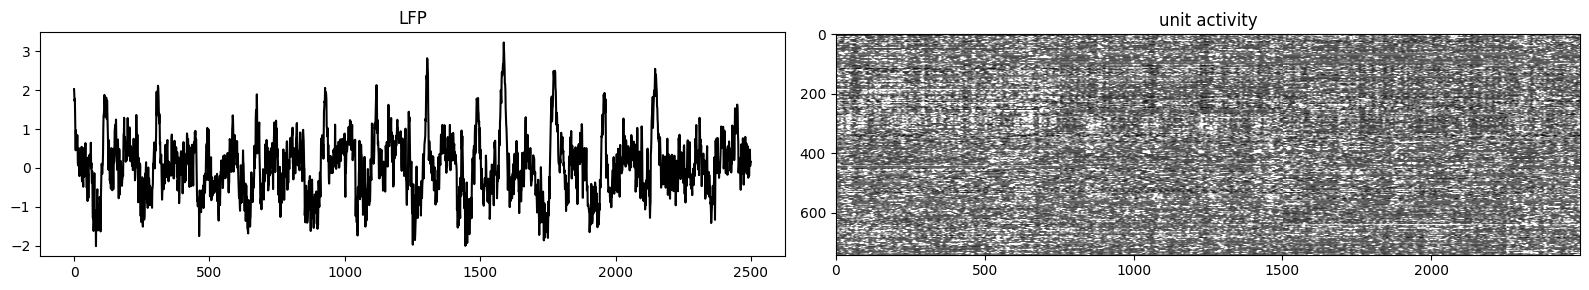

In [14]:
fig, ax = plt.subplots(1,2,figsize=(16, 3))

ax[0].plot(y_trainT.numpy()[:int(10/bin_size),10],'k',label='LFP')
# ax[0].plot(stats.zscore(np.mean(X_trainT.cpu().detach().numpy()[:int(10/bin_size),:], axis=1)),'r',label='unit activity')
ax[0].set_title('LFP')

ax[1].imshow(X_trainT.numpy()[:int(10/bin_size),:].T, vmin=-1, vmax=1, cmap='gray')
ax[1].set_title('unit activity')

plt.tight_layout()
plt.show()

In [19]:
criterion = torch.nn.MSELoss()
num_epochs = 15
lossesAll = np.zeros((y_trainT.shape[1], num_epochs))

# initialize dictionary to store trained models 
models = {}

for chani in range(y_trainT.shape[1]):
    sys.stdout.write('\r' + 'Training model for channel ' + str(chani) + ' out of ' + str(y_trainT.shape[1]))
    model = lstm.process_model(lstm.LSTMnet(input_size, hidden_size, num_layers), seqlength, criterion, device)
    models[chani] = model
    losses = model.train(X_trainT, y_trainT[:,chani].unsqueeze(1) , 15)
    lossesAll[chani,:] = losses

Finished epoch 15/15hannel 19 out of 20

Text(0.5, 1.0, 'Model loss')

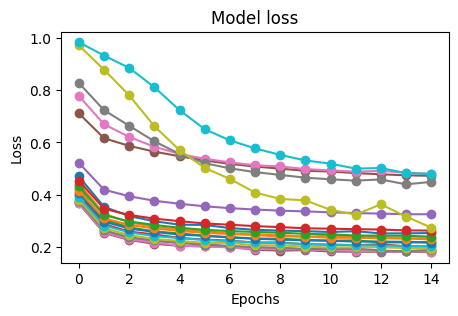

In [22]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

ax.plot(lossesAll.T,'o-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss')

In [29]:
model_scores = pd.DataFrame(columns=['r2_train', 'r2_test'])

for chani in range(y_trainT.shape[1]):
    yHat_train = models[chani].evaluate(X_trainT)
    r2_train = r2_score(y_trainT[:,chani].cpu().detach().numpy(), yHat_train)
    yHat_test = models[chani].evaluate(X_testT)
    r2_test = r2_score(y_testT[:,chani].cpu().detach().numpy(), yHat_test)
    model_scores.loc[chani] = [r2_train, r2_test]    

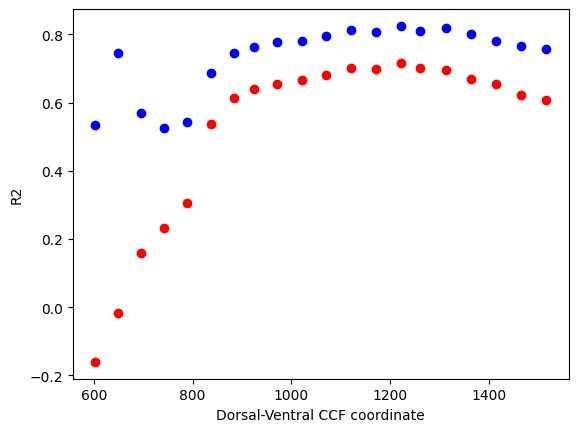

In [40]:
plt.scatter(visp_df['dorsal_ventral_ccf_coordinate'], model_scores['r2_train'], color = 'b', label='train')
plt.scatter(visp_df['dorsal_ventral_ccf_coordinate'], model_scores['r2_test'], color = 'r', label='test')
plt.xlabel('Dorsal-Ventral CCF coordinate')
plt.ylabel('R2')
plt.show()

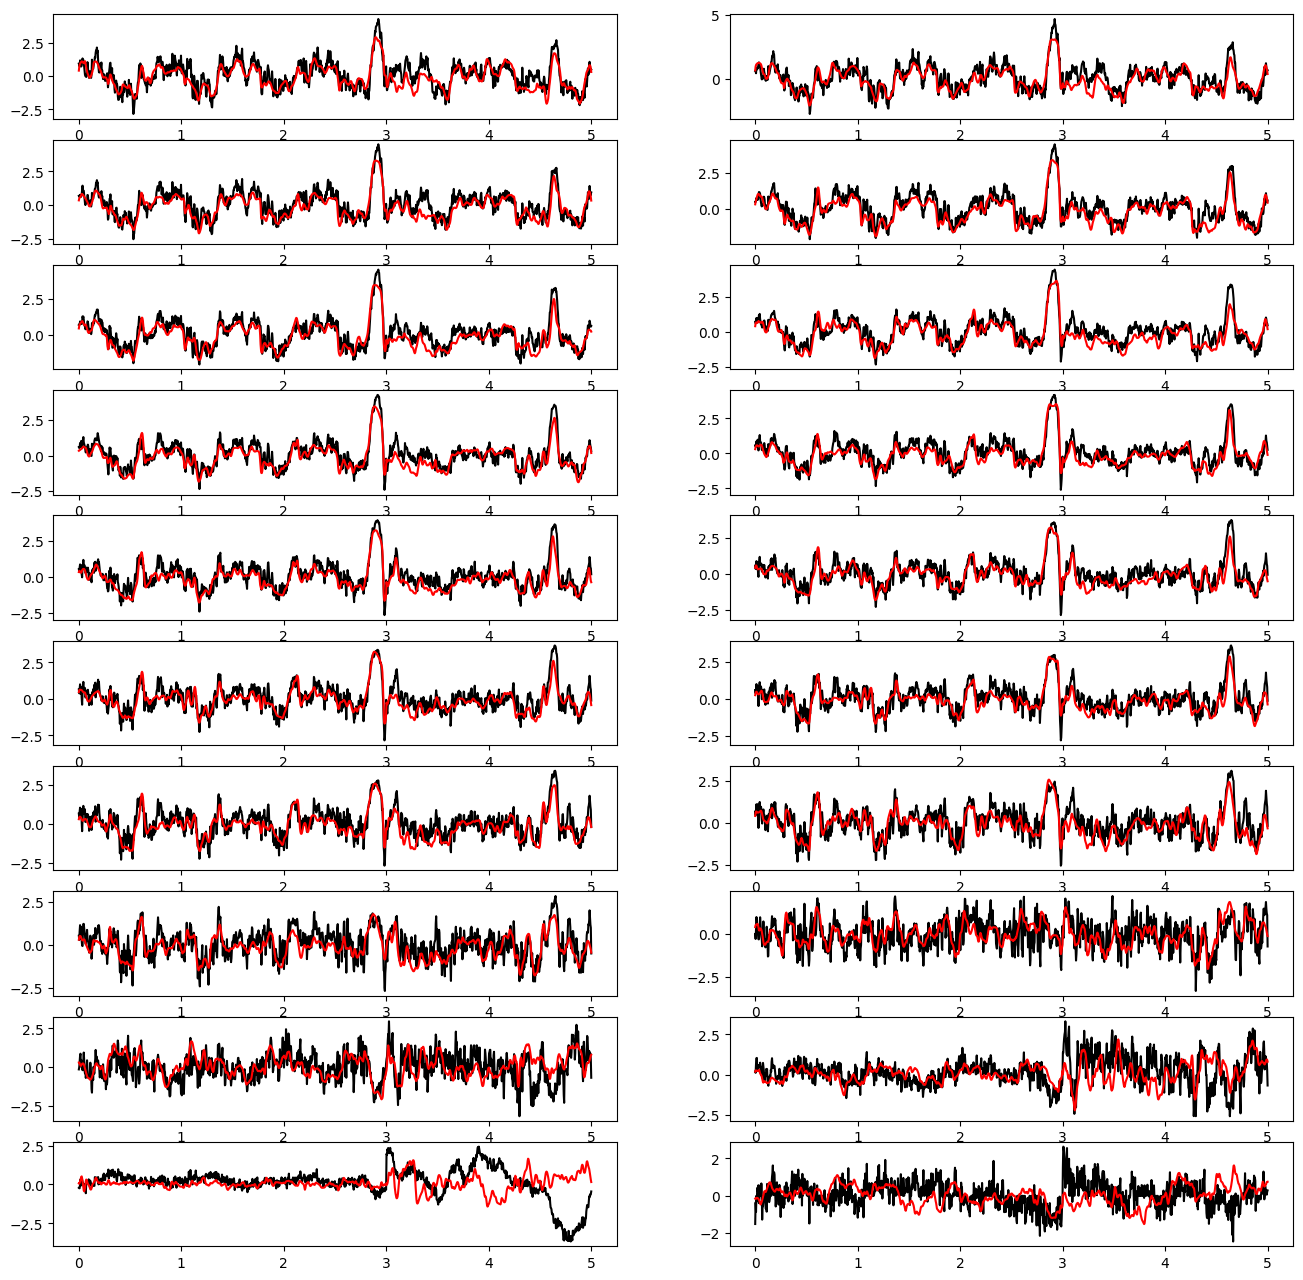

In [61]:
fig, ax = plt.subplots(int(np.ceil(y_trainT.shape[1]/2)),2, figsize=(16, 16))

for chani in range(y_trainT.shape[1]):
    yHat_test = models[chani].evaluate(X_testT)
    ax.flat[chani].plot(np.linspace(0,5,int(5/bin_size)), y_testT.cpu().detach().numpy()[:int(5/bin_size),chani],'k',label='LFP')
    ax.flat[chani].plot(np.linspace(0,5,int(5/bin_size)), yHat_test[:int(5/bin_size)],'r',label='LSTM')


In [75]:
# save the models
os.makedirs(output_dir / 'models' / str(session_id), exist_ok=True)
for idx, model in enumerate(models):
    filename = output_dir / 'models' / str(session_id) / f'lstm_model_{idx}.pt'
    torch.save(models[idx].model, filename)

In [82]:
# model.train()
X_testT = X_testT.to(device)

for chani in range(y_trainT.shape[1]):
# Initialize the attribution algorithm with the model
    sys.stdout.write('running atribution analysis to chan ' + str(chani) +'.\n')
    mdl = models[chani].model.train()
    integrated_gradients = IntegratedGradients(mdl)
    filename = output_dir / 'models' / str(session_id) / f'attribution_scores_{chani}.npy' 
    attributions = []
    for i in tqdm.tqdm(range(0,X_testT.shape[0],300)):
        attributions.append(integrated_gradients.attribute(X_testT[i:i+300,:].contiguous(),  target=0,  n_steps=200))
    attributions = torch.cat(attributions)
    attributions = attributions.cpu().detach().numpy()
    np.save(filename, attributions, 'allow_pickle=True')

running atribution analysis to chan 0.


100%|██████████| 603/603 [17:27<00:00,  1.74s/it]


running atribution analysis to chan 1.


100%|██████████| 603/603 [17:39<00:00,  1.76s/it]


running atribution analysis to chan 2.


100%|██████████| 603/603 [17:40<00:00,  1.76s/it]


running atribution analysis to chan 3.


 81%|████████▏ | 491/603 [14:25<03:22,  1.80s/it]